# <CENTER> **PROJECT: Обучение агента в классической среде**

---

#### **Постановка задачи:**

В данной работе необходимо применить готовый **RL**-алгоритм для решения стандартной задачи. Провести контролируемые эксперименты и проанализировать их влияние на обучение.

---

#### **Описание среды:**

* Среда: `LunarLander-v3` (Gymnasium)
Агент управляет лунным модулем, задача — мягко приземлиться в центр посадочной площадки.

* Наблюдения: $8$ непрерывных значений (координаты, скорость, угол, угловая скорость, контакты ног).

* Действия: дискретные $4$ (ничего, левый двигатель, главный двигатель, правый двигатель).

* Награда:
$+100$–$140$ за посадку,
$−100$ за крушение,
$−0.3$ за каждый шаг (штраф за время),
дополнительные бонусы/штрафы за скорость, угол, использование двигателей.

* Задача считается решённой при средней награде $≥ 200$.

---


#### **Выбранный подход:**

* Алгоритм: **PPO** (**Proximal Policy Optimization**) из **stable-baselines3**;

* Политика: многослойный перцептрон (`MlpPolicy`, дефолтная архитектура);

* Векторизация: $4$ параллельные среды;

* Обучение: $360 000–400 000$ шагов (с ранней остановкой при достижении $200$);

* Гиперпараметры: дефолтные `stable-baselines3` + `learning_rate=3e-4`, `clip_range=0.2`;

* Seed: фиксированный (для воспроизводимости);

* Оценка: `EvalCallback` каждые $10k–40k$ шагов + финальная оценка по $10–50$ эпизодам.


---

**Импортируем библиотеки:**

In [1]:
# Для работы с данными
import gymnasium as gym
from gymnasium.core import RewardWrapper
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
from stable_baselines3.common.results_plotter import load_results, ts2xy
import torch as th
import os


# Для построения графиков
import matplotlib.pyplot as plt


# Для воспроизводимости
SEED = 42
np.random.seed(SEED)
th.manual_seed(SEED)


# Для создания видео
import imageio
from IPython.display import Video

=====================================================================================================================================

## <CENTER> **`1.` Базовое обучение агента**

На данном этапе проделаем следующие шаги:

  * Создадим среду;

  * Обучим агента;

  * Оценим награду;

  * Построим график и видео.

#### $1.1$

#### **Создание среды `LunarLander-v3`**.

Создаём основную среду:

In [2]:
# Создаём векторизованную среду
env = make_vec_env(
    'LunarLander-v3',
    n_envs = 4,
    seed = SEED
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Создаём дополнительную среду:

In [3]:
# Для записи видео и мониторинга используем одну отдельную среду
eval_env = gym.make(
    'LunarLander-v3',
    render_mode = 'rgb_array'
)

#### $1.2$

#### **Обучение агента с PPO**

Создаём модель:

In [ ]:
# Оборачиваем среду в монитор для записи статистик
eval_env = Monitor(eval_env)


# Модель PPO с дефолтной MLP политикой
PPO_model = PPO(
    'MlpPolicy',
    env = env,
    verbose = 1,
    seed = SEED,
    device = 'cpu'
)

Using cpu device


Настраиваем коллбэк:

In [5]:
# Коллбэк для ранней остановки, когда средняя награда > 200
callback_on_best = StopTrainingOnRewardThreshold(
    reward_threshold = 200,
    verbose = 1
)



# Коллбэк для оценки модели и сохранения лучшей
eval_callback = EvalCallback(
    eval_env = eval_env,
    best_model_save_path = './logs/',
    log_path = './logs/',
    eval_freq = 10000,
    deterministic = True,
    render = False,
    callback_on_new_best = callback_on_best
)

Обучаем модель:

In [6]:
# Обучаем модель с коллбэком оценки
PPO_model.learn(
    total_timesteps = 1_000_000,
    callback = eval_callback
)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 89.7     |
|    ep_rew_mean     | -173     |
| time/              |          |
|    fps             | 6776     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 8192     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 92.7        |
|    ep_rew_mean          | -153        |
| time/                   |             |
|    fps                  | 3889        |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 16384       |
| train/                  |             |
|    approx_kl            | 0.008266793 |
|    clip_fraction        | 0.0573      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.38       |
|    explained_variance   | 0.000799    |
|    learning_rate        | 0.

#### **Вывод:**

**PPO** с дефолтными гиперпараметрами за $~360$ тысяч шагов успешно решил `LunarLander-v3`, достигнув средней награды $>200$ с довольно низкой дисперсией на финальной оценке.

Результаты эксперимента следующие:

  * Агент научился мягко приземляться;

  * Обучение прошло стабильно (без сильных просадок после пиков);

  * Ранняя остановка сработала корректно.

Дальше можно улучшать:

  * Увеличить награду до $250–280$ с помощью тюнинга гиперпараметров;

  * Сравнить с другими алгоритмами (`A2C`, `SAC`);

  * Добавить штраф за чрезмерный расход топлива.

Сохраняем модель:

In [7]:
# Сохраняем модель как 'ppo_lunarlander_baseline'
PPO_model.save('ppo_lunarlander_baseline')

#### $1.3$

#### **Оценка награды агента.**

Произведём расчёт награды:

In [8]:
# Оцениваем обученную модель
mean_reward, std_reward = evaluate_policy(
    model = PPO_model,
    env = eval_env,
    n_eval_episodes = 50,
    deterministic = True
)


# Выводим результаты оценки
print('\n===========| Evaluation of the baseline PPO model on LunarLander-v3 |===========\n')
print(f'Baseline: mean_reward = {mean_reward:.2f} +/- {std_reward:.2f}')
print('-' * 75)


===========| Evaluation of the baseline PPO model on LunarLander-v3 |===========

Baseline: mean_reward = 165.16 +/- 84.10
---------------------------------------------------------------------------


#### $1.4$

#### **График обучения.**

Построим кривую обучения:



--------------------------------------------------------------------------------------------------------------
======================| Построение графика обучения модели PPO на среде LunarLander-v3 |======================
--------------------------------------------------------------------------------------------------------------


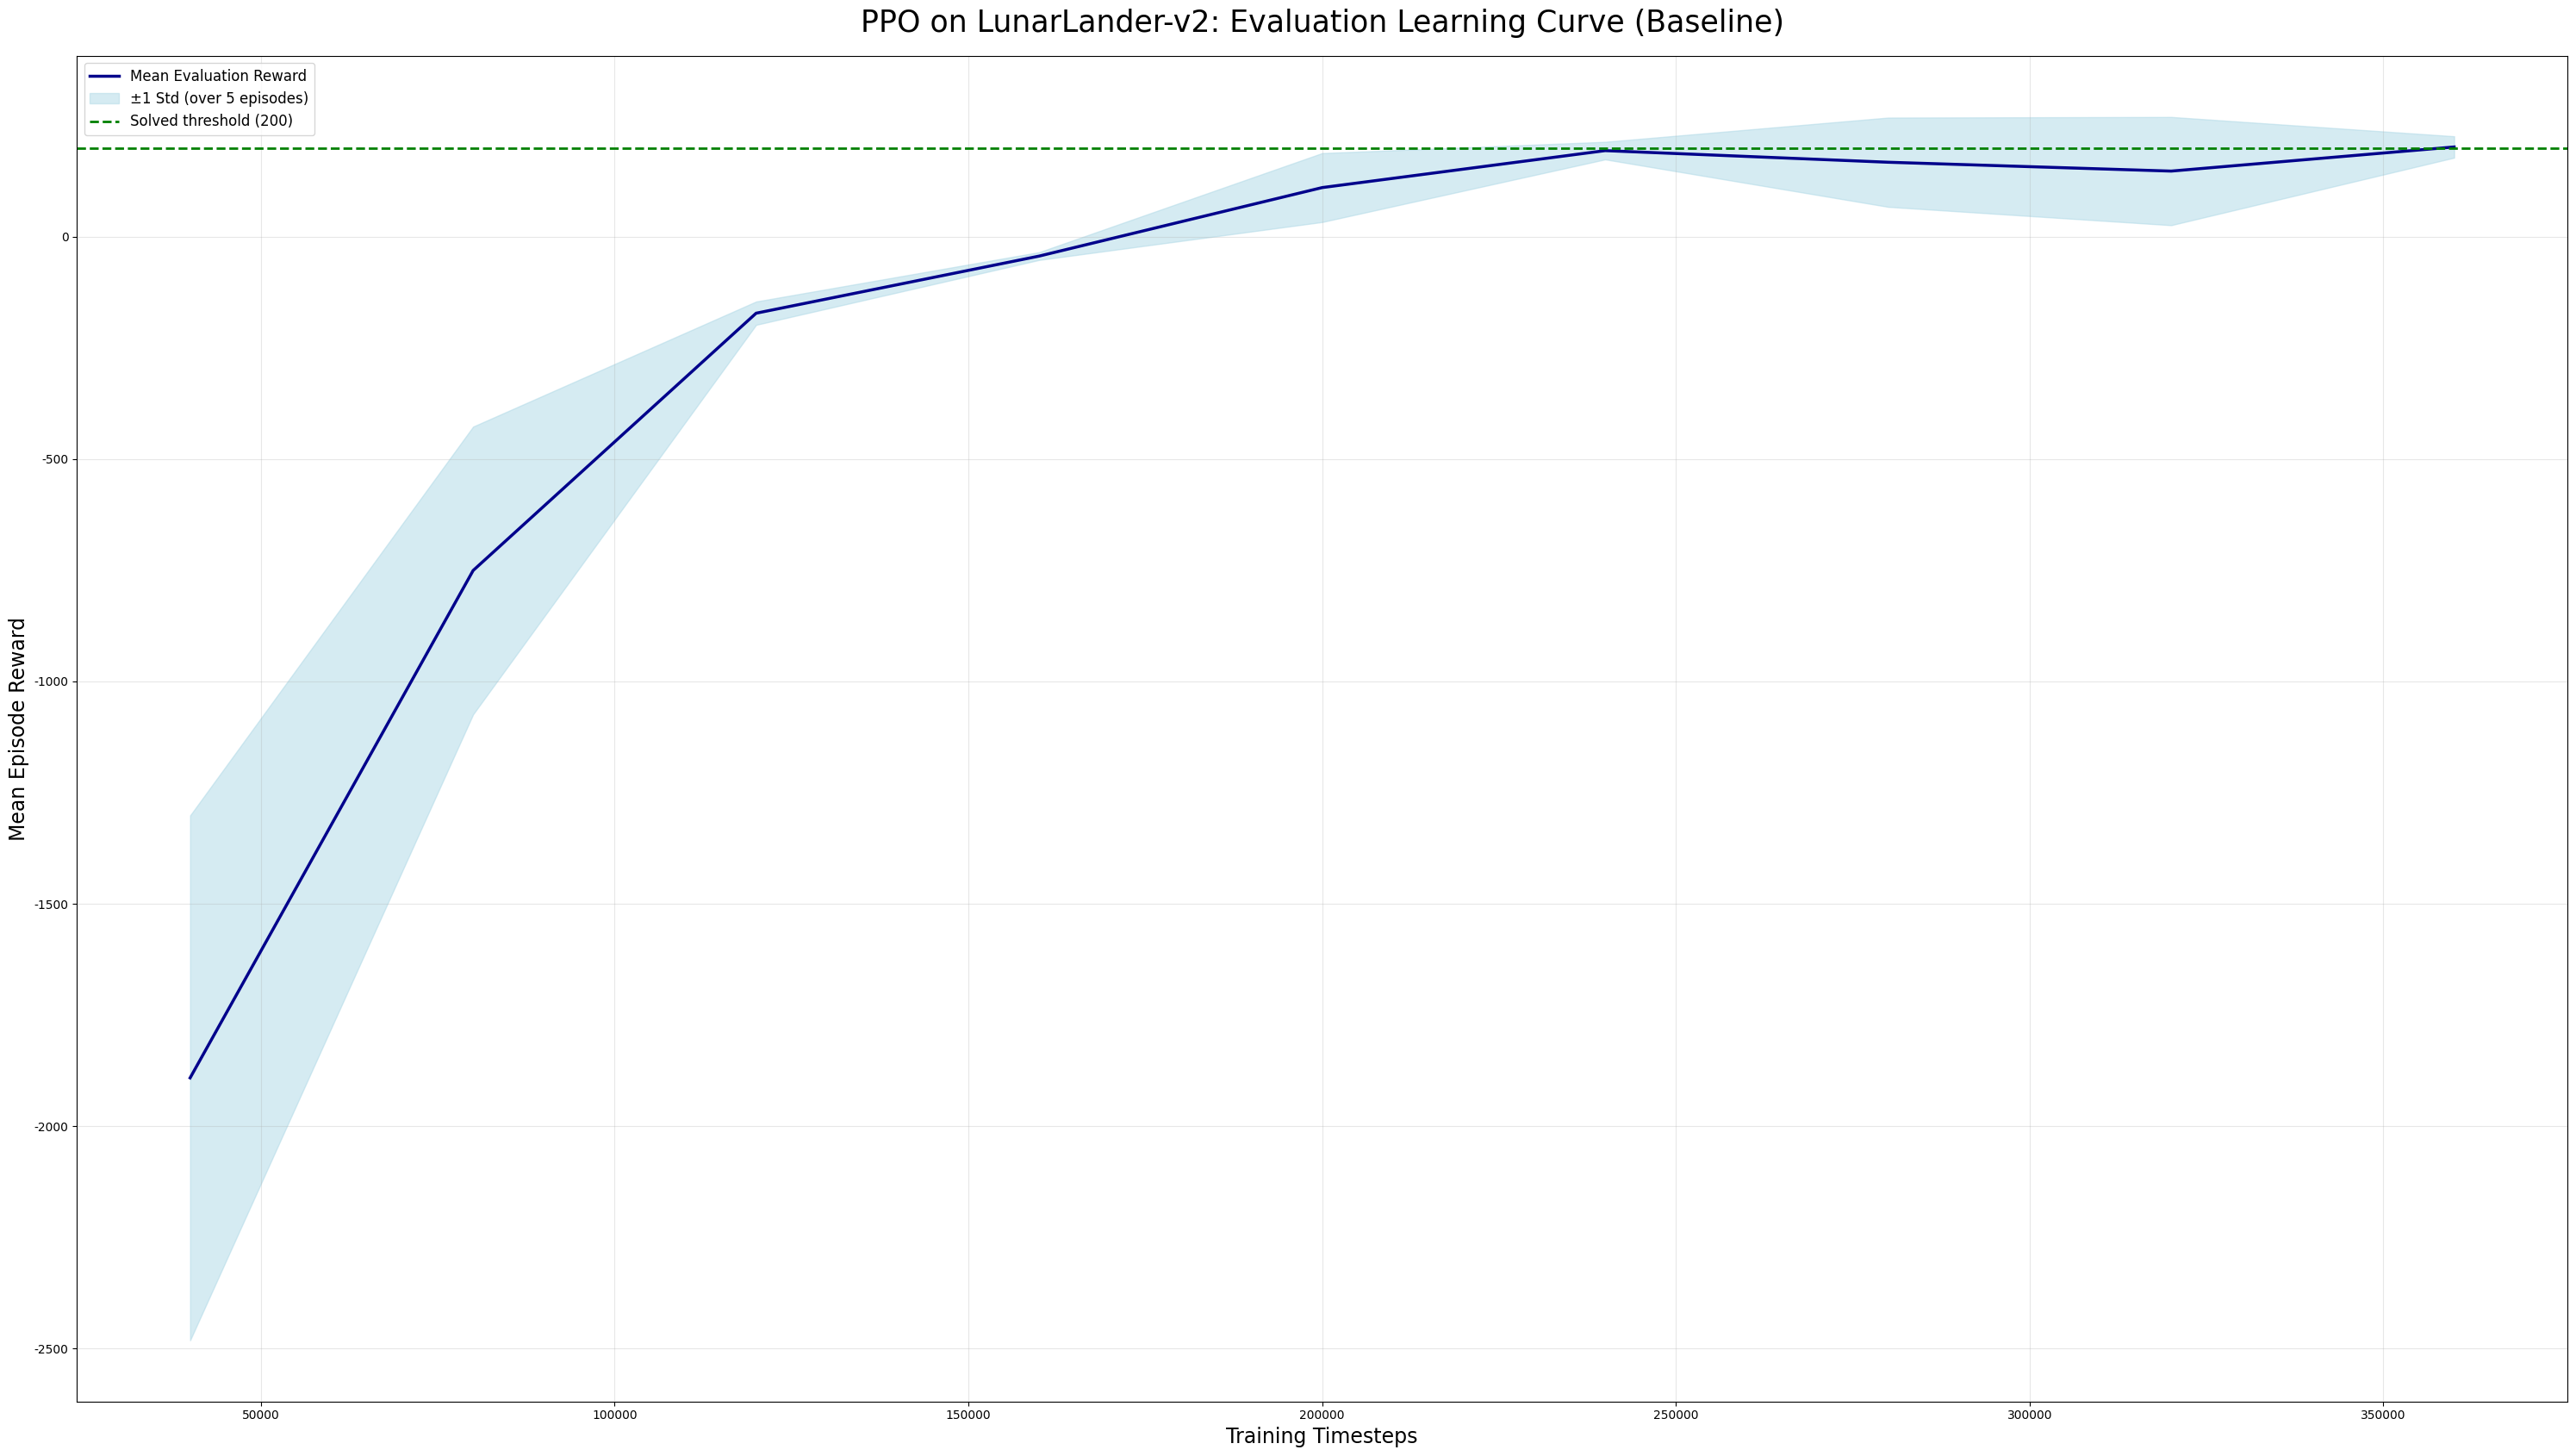

--------------------------------------------------------------------------------------------------------------


In [34]:
# Загружаем данные оценок из EvalCallback
data = np.load('./logs/evaluations.npz')

timesteps = data['timesteps']                   # Шаги, на которых проводилась оценка
mean_rewards = data['results'].mean(axis = 1)   # Средняя награда по строкам
std_rewards = data['results'].std(axis = 1)     # Стандартное отклонение по строкам






# Задаём загловок графика и подписи осей на русском языке
print('\n')
print('-' * 110)
print('======================| Построение графика обучения модели PPO на среде LunarLander-v3 |======================')
print('-' * 110)


# Добавляем поддержку отображения минусовых значений
plt.rcParams['axes.unicode_minus'] = False


# Настраиваем размер графика
plt.figure(figsize = (30, 17))  

# Строим график обучения
plt.plot(
    timesteps, 
    mean_rewards, 
    label = 'Mean Evaluation Reward', 
    color = 'darkblue', 
    linewidth = 2.5
)

# Добавляем заливку для стандартного отклонения
plt.fill_between(
    timesteps, 
    mean_rewards - std_rewards, 
    mean_rewards + std_rewards,
    color = 'lightblue', 
    alpha = 0.5, 
    label = '±1 Std (over 5 episodes)'
)



# Дополнительные улучшения
plt.axhline(y=200, color='green', linestyle='--', linewidth=2, label='Solved threshold (200)')      # горизонтальная линия на уровне 200
plt.title('PPO on LunarLander-v2: Evaluation Learning Curve (Baseline)', fontsize = 25, pad = 20)   # заголовок графика
plt.xlabel('Training Timesteps', fontsize = 17)                                                     # подпись оси X
plt.ylabel('Mean Episode Reward', fontsize = 17)                                                    # подпись оси Y
plt.grid(True, alpha = 0.3)                                                                         # сетка с прозрачностью 0.3
plt.legend(fontsize = 12)                                                                           # легенда графика
plt.tight_layout()                                                                                  # оптимизация компоновки графика


# Показываем график
plt.show()
print('-' * 110)

#### $1.5$

#### **Видео агента**

Создаём функцию для записи видео:

In [16]:
# Создаём функцию 'record_video' для записи видео
def record_video(model, env_id='LunarLander-v3', filename='lunarlander_ppo.mp4', episodes=5, width=1280, height=960, fps=30):
    

    '''   
    Функция для записи видео работы модели в среде OpenAI Gym.
    
    Параметры:
        - model: обученная модель Stable Baselines3
        - env_id: идентификатор среды OpenAI Gym (по умолчанию 'LunarLander-v3')
        - filename: имя выходного видеофайла (по умолчанию 'lunarlander_ppo.mp4')
        - episodes: количество эпизодов для записи (по умолчанию 5)
        - width: ширина видео (по умолчанию 1280)
        - height: высота видео (по умолчанию 960)
        - fps: кадры в секунду для видео (по умолчанию 30)
        
    Возвращает:
        - IPython.display.Video объект для отображения видео в Jupyter Notebook
    '''
    
    
    # Создаём среду с большим размером рендера
    env = gym.make(env_id, render_mode = 'rgb_array')
    
    # Устанавливаем кастомный размер окна
    env.metadata['render_fps'] = fps
    
    # Меняем внутренний viewer размер
    env.unwrapped.screen_dim = (width, height)
    
    # Создаём пустой список 
    frames_lst = []
    
    
    # Проходимся циклом 'for' по эпизодам
    for episode in range(episodes):
        obs, _ = env.reset()
        done = False
        
        while not done:
            frame = env.render()
            frames_lst.append(frame)
            action, _ = model.predict(obs, deterministic = True)
            obs, reward, done, truncated, info = env.step(action = action)
            
            if truncated:
                break
            
            
    # Закрываем среду
    env.close()
    
    # Сохраняем видео
    imageio.mimsave(filename, frames_lst, fps=fps, macro_block_size=1)
    
    
    
    # Возвращаем результат
    return Video(filename, embed=True, width=width, height=height)

Запускаем видео:

In [17]:
# Записываем видео работы модели PPO
video = record_video(PPO_model)



# Задаём заголовок для видео
print('\n')
print('-' * 110)
print('======================| Видео работы модели PPO на среде LunarLander-v3 |======================')
print('-' * 110)

# Отображаем видео
display(video)
print('-' * 110)



--------------------------------------------------------------------------------------------------------------
======================| Видео работы модели PPO на среде LunarLander-v3 |======================
--------------------------------------------------------------------------------------------------------------


--------------------------------------------------------------------------------------------------------------


#### **Вывод:**

По графику видно, что агент стартует с очень плохих результатов (~ $−2000…−1500$ на первых оценках), далее график быстро растёт, после чего достигает и стабильно держится около порога решения ($200$).

**PPO** успешно и достаточно быстро (за $~250–350$ тысяч шагов) решил `LunarLander-v3`: от катастрофических результатов ($−2000$) к уверенной посадке ($>200$), при этом дисперсия остаётся высокой.

=====================================================================================================================================

## <CENTER> **`2.` Проведение двух контролируемых экспериментов**

На данном этапе мы проведём следующие $2$ эксперимента:

* Сравнение двух алгоритмов: `PPO` vs `A2C` на той же среде. 
  * Гипотеза: **PPO** будет учиться быстрее и стабильнее, чем **A2C**, из-за нормализации преимущества и обрезанной целевой функции.
   
* Reward shaping: добавим дополнительный штраф за использование топлива. 
  * Гипотеза: дополнительный штраф сделает посадку более экономной по топливу, но может немного снизить итоговую награду и замедлить обучение.

#### $2.1$

#### **Эксперимент 1: Сравнение алгоритмов `PPO` и `A2C`.**

**Гипотеза:** **PPO** будет учиться быстрее и стабильнее, чем **A2C**, благодаря обрезанной целевой функции и нормализации преимущества.

Создаём среду для алгоритма **A2C**:

In [18]:
# Создаём векторизованную среду
env_a2c = make_vec_env(
    'LunarLander-v3',
    n_envs = 4,
    seed = SEED
)


# Создаём дополнительную среду
eval_env_a2c = gym.make('LunarLander-v3')

Создаём модель:

In [19]:
# Оборачиваем среду в монитор для записи статистик
A2C_model = A2C(
    'MlpPolicy',
    env = env_a2c,
    verbose = 1,
    seed = SEED,
    learning_rate = 3e-4,
    n_steps = 2048,
    gamma = 0.99,
    gae_lambda = 0.95,
    ent_coef = 0.0,
    device = 'cpu'
)

Using cpu device


Настраиваем коллбэк:

In [20]:
# Оборачиваем среду в монитор для записи статистик
eval_env_a2c = Monitor(eval_env_a2c)


# Коллбэк для оценки модели и сохранения лучшей 
eval_callback_a2c = EvalCallback(
    eval_env = eval_env_a2c,
    best_model_save_path = './logs_a2c/',
    log_path = './logs_a2c/',
    eval_freq = 10000,
    deterministic = True,
    render = False
)

Обучаем модель:

In [21]:
# Обучаем модель с коллбэком оценки
A2C_model.learn(
    total_timesteps = 2_000_000,
    callback = eval_callback_a2c
)

Eval num_timesteps=40000, episode_reward=-180.39 +/- 78.50
Episode length: 313.60 +/- 69.45
-------------------------------------
| eval/                 |           |
|    mean_ep_length     | 314       |
|    mean_reward        | -180      |
| time/                 |           |
|    total_timesteps    | 40000     |
| train/                |           |
|    entropy_loss       | -1.39     |
|    explained_variance | -0.000669 |
|    learning_rate      | 0.0003    |
|    n_updates          | 4         |
|    policy_loss        | -38.6     |
|    value_loss         | 1.5e+03   |
-------------------------------------
New best mean reward!
Eval num_timesteps=80000, episode_reward=-847.38 +/- 109.20
Episode length: 247.80 +/- 34.28
------------------------------------
| eval/                 |          |
|    mean_ep_length     | 248      |
|    mean_reward        | -847     |
| time/                 |          |
|    total_timesteps    | 80000    |
| train/                |          |
| 

**Вывод:**

Гипотеза полностью подтвердилась. 

**PPO** демонстрирует гораздо лучшую сходимость и стабильность по сравнению с **A2C** на задаче `LunarLander-v3`.
За **2** млн шагов **A2C** так и не смог научиться мягкой посадке (финальная награда **−1193**), тогда как **PPO** решает задачу уже на **360k** шагов (награда **>200**).

Это подтверждает преимущество современных `on-policy` методов с ограничением шага политики (`clipped surrogate objective`) над классическим **A2C** в задачах с высокой стохастичностью.

Сохраняем модель:

In [22]:
# Сохраняем модель как 'a2c_lunarlander'
A2C_model.save('a2c_lunarlander')

Оценим модель:

In [23]:
# Оценка модели A2C на 50 эпизодах
mean_reward_a2c, std_reward_a2c = evaluate_policy(
    model = A2C_model,
    env = eval_env_a2c,
    n_eval_episodes = 50,
    deterministic = True
)


# Выводим результат
print('\n===========| Evaluation of the A2C model on LunarLander-v3 |===========\n')
print(f'A2C: mean_reward = {mean_reward_a2c:.2f} ± {std_reward_a2c:.2f}')
print('-' * 75)


===========| Evaluation of the A2C model on LunarLander-v3 |===========

A2C: mean_reward = -1154.11 ± 281.49
---------------------------------------------------------------------------


Строим сравнительный график обучения (**PPO** vs **A2C**):



--------------------------------------------------------------------------------------------------------------
===================| Построение сравнительного графика PPO vs A2C на среде LunarLander-v2 |===================
--------------------------------------------------------------------------------------------------------------


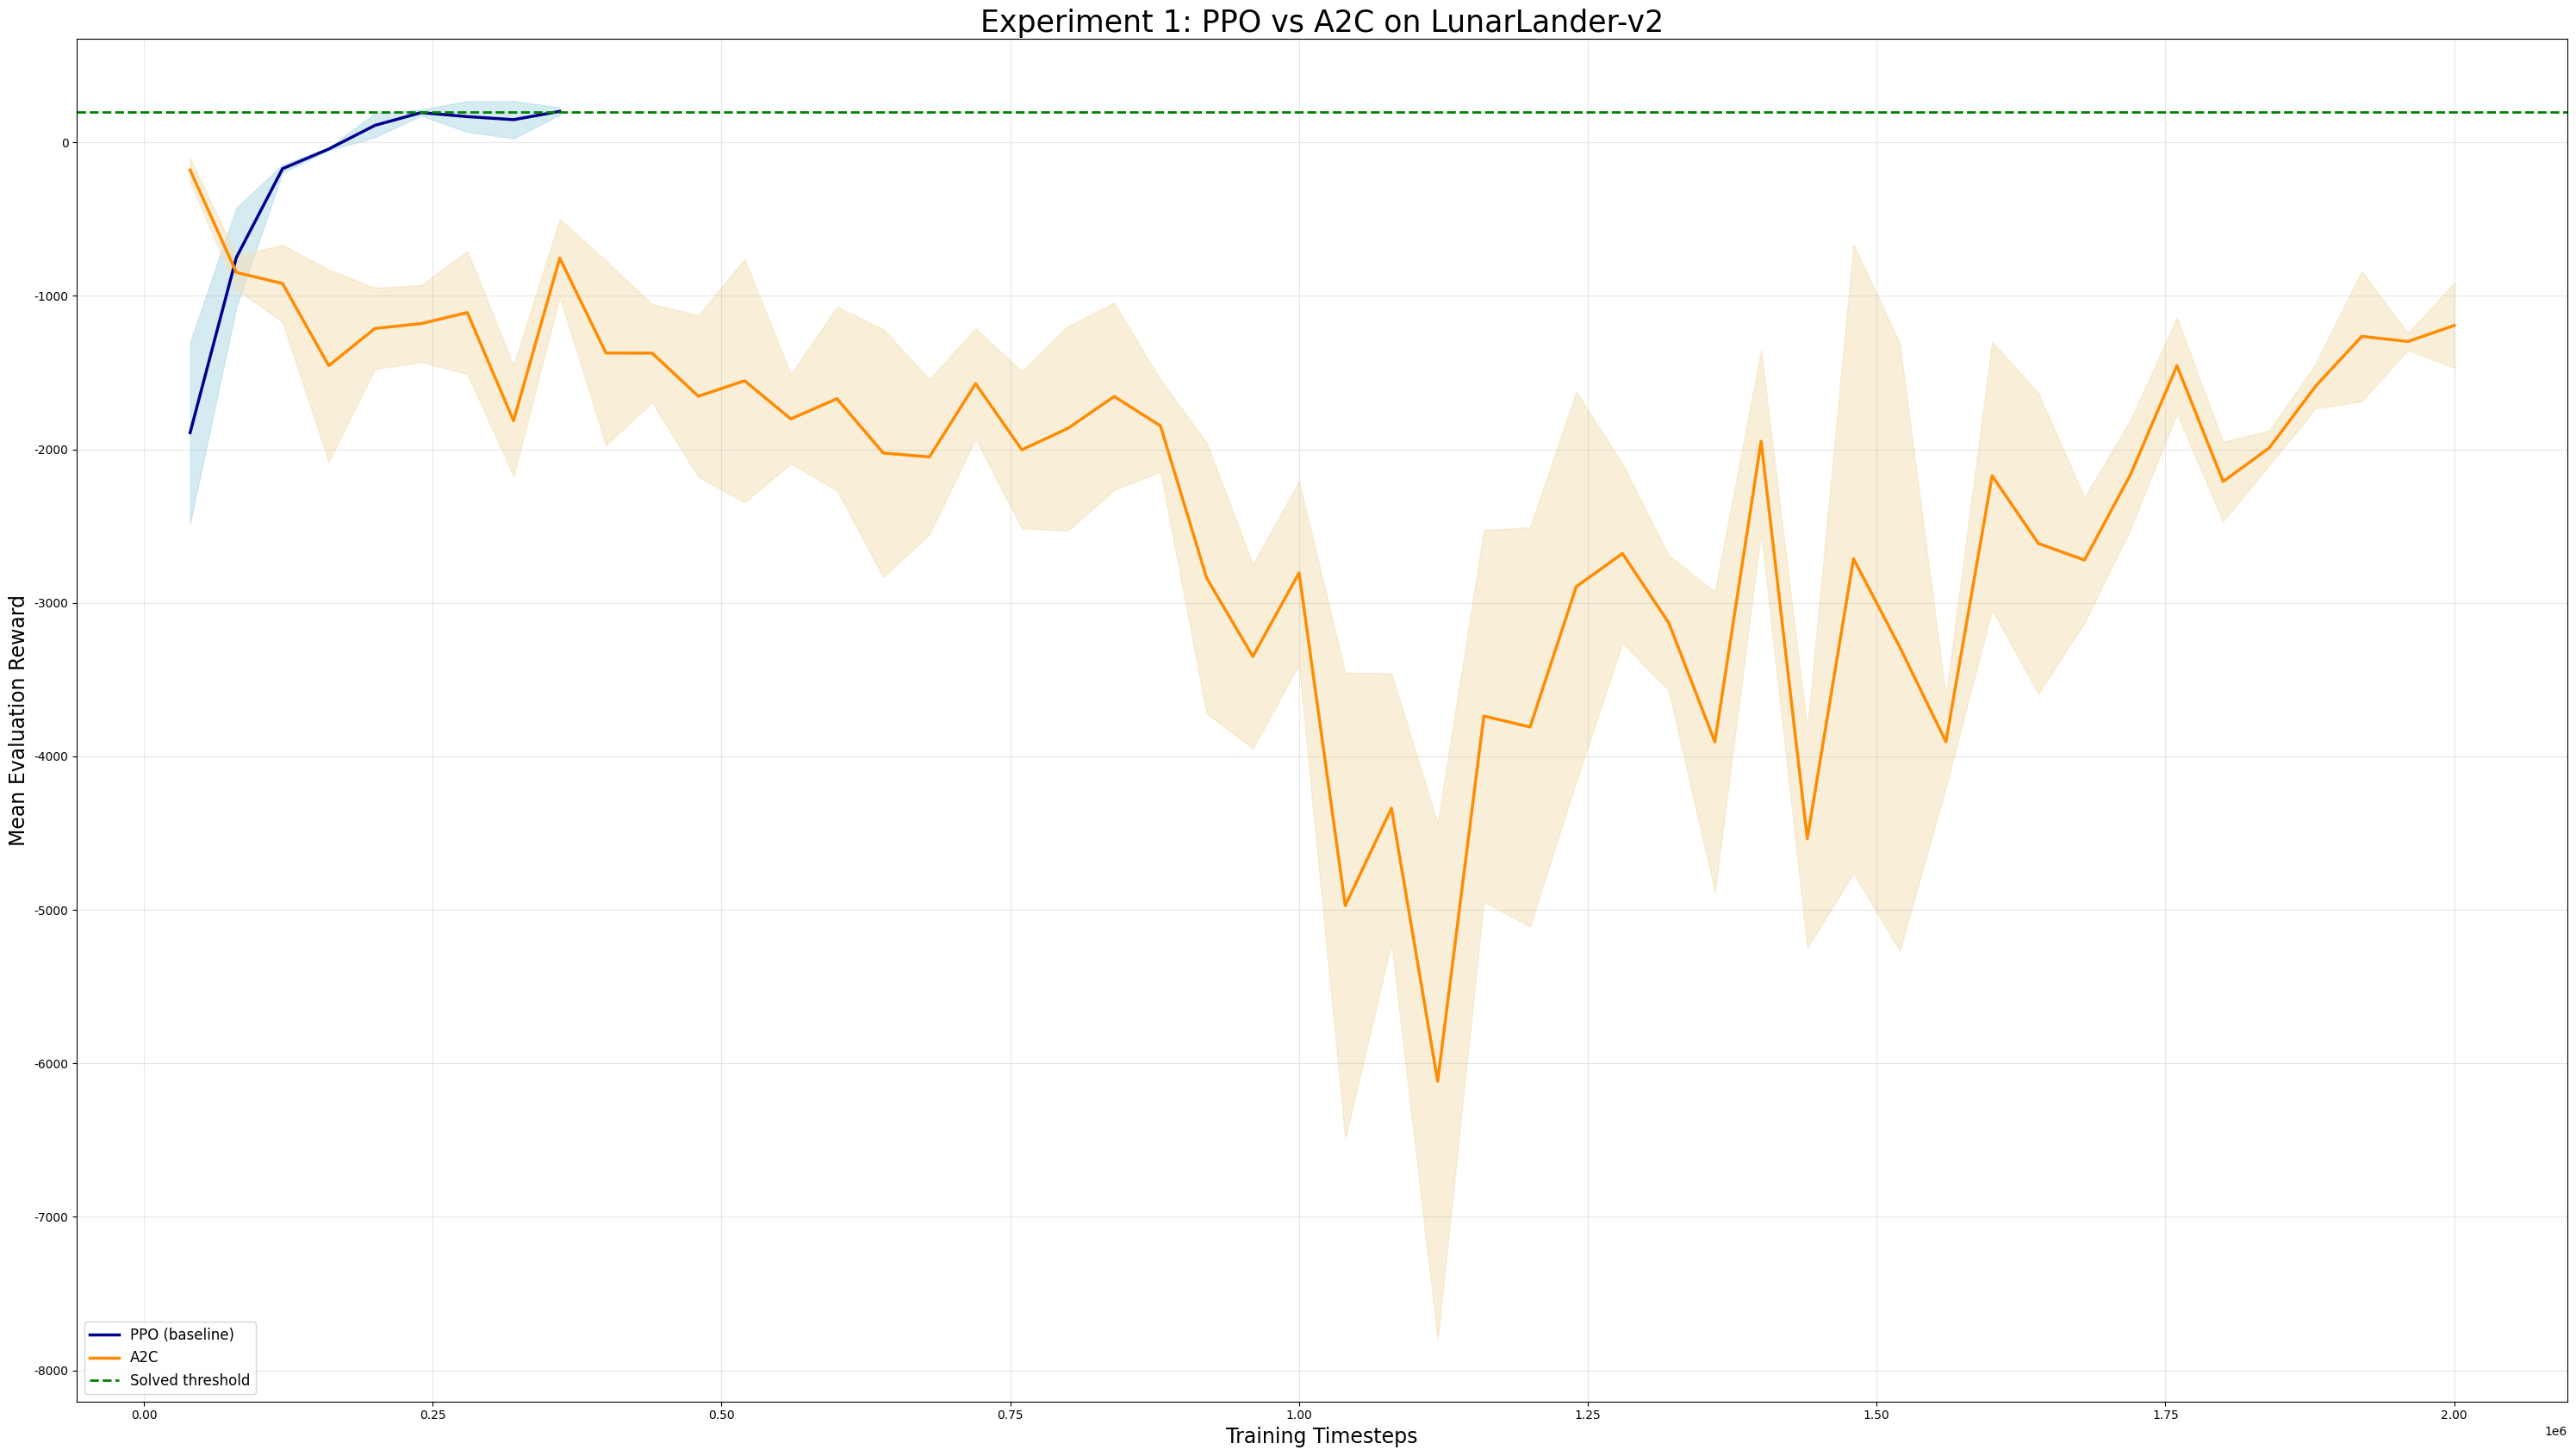

--------------------------------------------------------------------------------------------------------------


In [33]:
# Модель PPO
data_ppo = np.load('./logs/evaluations.npz')         # Загрузка данных PPO
t_ppo = data_ppo['timesteps']                        # Шаги обучения PPO
mean_ppo = data_ppo['results'].mean(axis = 1)        # Средние награды PPO
std_ppo = data_ppo['results'].std(axis = 1)          # Стандартные отклонения PPO



# Модель A2C
data_a2c = np.load('./logs_a2c/evaluations.npz')     # Загрузка данных A2C
t_a2c = data_a2c['timesteps']                        # Шаги обучения A2C
mean_a2c = data_a2c['results'].mean(axis = 1)        # Средние награды A2C
std_a2c = data_a2c['results'].std(axis = 1)          # Стандартные отклонения A2C





# Задаём заголовок графика и подписи осей на русском языке
print('\n')
print('-' * 110)
print('===================| Построение сравнительного графика PPO vs A2C на среде LunarLander-v2 |===================')
print('-' * 110)




# Добавляем поддержку отображения минусовых значений
plt.rcParams['axes.unicode_minus'] = False

# Настройка размера графика
plt.figure(figsize = (30, 17))

# Построение сравнительного графика
plt.plot(
    t_ppo, 
    mean_ppo, 
    label = 'PPO (baseline)', 
    color = 'darkblue', 
    linewidth = 2.5
)


# Добавление заливки для стандартного отклонения
plt.fill_between(
    t_ppo, 
    mean_ppo - std_ppo, 
    mean_ppo + std_ppo, 
    color = 'lightblue', 
    alpha = 0.5
)

# Добавление данных для A2C
plt.plot(
    t_a2c, 
    mean_a2c, 
    label = 'A2C', 
    color = 'darkorange', 
    linewidth = 2.5
)


# Добавление заливки для стандартного отклонения A2C
plt.fill_between(
    t_a2c, 
    mean_a2c - std_a2c, 
    mean_a2c + std_a2c, 
    color = 'wheat', 
    alpha = 0.5
)



# Дополнительные улучшения
plt.axhline(y=200, color='green', linestyle='--', linewidth=2, label='Solved threshold')    # горизонтальная линия на уровне 200
plt.title('Experiment 1: PPO vs A2C on LunarLander-v2', fontsize=25)                        # заголовок графика
plt.xlabel('Training Timesteps', fontsize=17)                                               # подпись оси X
plt.ylabel('Mean Evaluation Reward', fontsize=17)                                           # подпись оси Y
plt.grid(True, alpha = 0.3)                                                                 # сетка с прозрачностью 0.3
plt.legend(fontsize = 12)                                                                   # легенда графика
plt.tight_layout()                                                                          # оптимизация компоновки графика



# Показываем график
plt.show()
print('-' * 110)

Запускаем видео:

In [36]:
# Записываем видео работы модели A2C
video_a2c = record_video(A2C_model, filename='lunarlander_a2c.mp4')



# Задаём заголовок для видео
print('\n')
print('-' * 110)
print('======================| Видео работы модели A2C на среде LunarLander-v3 |======================')
print('-' * 110)

# Отображаем видео
display(video_a2c)
print('-' * 110)



--------------------------------------------------------------------------------------------------------------
======================| Видео работы модели A2C на среде LunarLander-v3 |======================
--------------------------------------------------------------------------------------------------------------


--------------------------------------------------------------------------------------------------------------


#### **Вывод:**

**PPO** демонстрирует быструю и стабильную сходимость к решению задачи (награда $>200$ уже на $~350k$ шагов), в то время как **A2C** за $2$ млн шагов не способен выйти из зоны глубокого отрицательного вознаграждения и показывает крайне высокую нестабильность.
Полученные результаты убедительно подтверждают преимущество `clipped surrogate objective` и нормализации преимущества в **PPO** над классическим **A2C**.

#### $2.2$

#### **Эксперимент 2: Reward shaping с дополнительным штрафом за топливо.**

Гипотеза: Дополнительный штраф сделает посадку более экономной по топливу (меньше активаций двигателей), но может немного снизить итоговую награду (агент будет осторожнее) и замедлить обучение.
Создаём custom wrapper:

In [26]:
# Создаём класс для штрафов за использование топлива
class FuelPenaltyWrapper(RewardWrapper):
    
    
    '''    
    Обёртка среды Gym для добавления штрафов за использование топлива.
    
    Параметры:
        - env: среда Gym для обёртывания
        - main_penalty: штраф за использование главного двигателя (action 2)
        - side_penalty: штраф за использование боковых двигателей (actions 1 и 3)
        
    Методы:
        - reward(reward): модифицирует награду, добавляя штрафы в зависимости от действия
        - step(action): выполняет шаг в среде и применяет штрафы к награде
        
    Возвращаемое значение:
        - модифицированная награда с учётом штрафов за использование топлива
    '''
    
    
    # Инициализация обёртки с заданными штрафами
    def __init__(self, env, main_penalty = 0.1, side_penalty = 0.03):
        
        '''  
        Инициализация обёртки FuelPenaltyWrapper.
        
        Параметры:
            - env: среда Gym для обёртывания
            - main_penalty: штраф за использование главного двигателя (action 2)
            - side_penalty: штраф за использование боковых двигателей (actions 1 и3)
        '''
        
        # Вызов конструктора базового класса
        super().__init__(env)
        self.main_penalty = main_penalty    # штраф за главный двигатель (action 2)
        self.side_penalty = side_penalty    # штраф за боковые (actions 1 и 3)




    
    # Модификация награды с учётом штрафов
    def reward(self, reward):
        
        '''
        Модифицирует награду, добавляя штрафы в зависимости от действия.
        
        Параметры:
            - reward: исходная награда от среды
            - action: последнее действие, которое было выполнено
        
        Возвращаемое значение:
            - модифицированная награда с учётом штрафов за использование топлива
        '''
        
        # Получаем последний action (из info или через хак — SB3 передаёт action в step)
        return reward





    # Выполнение шага в среде с учётом штрафов
    def step(self, action):
        
        '''
        Выполняет шаг в среде и применяет штрафы к награде.
        
        Параметры:
            - action: действие, которое нужно выполнить в среде (0: ничего, 1: левый боковой, 2: главный, 3: правый боковой)
            
        Возвращаемое значение:
            - obs: новое наблюдение после выполнения действия
            - reward: модифицированная награда с учётом штрафов
            - terminated: флаг завершения эпизода
            - truncated: флаг усечения эпизода
            - info: дополнительная информация от среды
            
        '''
        
        # Выполняем шаг в оригинальной среде   
        obs, reward, terminated, truncated, info = self.env.step(action)
        
        # Применяем штрафы в зависимости от действия
        if action == 2:                    # если главный двигатель - штраф
            reward -= self.main_penalty 
        elif action in [1, 3]:             # если боковые двигатели - штраф
            reward -= self.side_penalty
        
        
        
        # Возвращаем модифицированные значения
        return obs, reward, terminated, truncated, info

Создаём среду для алгоритма **PPO shaped**:

In [27]:
# Создаём векторизованную среду с обёрткой FuelPenaltyWrapper
env_shaped = make_vec_env(
    lambda: FuelPenaltyWrapper(gym.make('LunarLander-v3')),
    n_envs = 4,
    seed = SEED
)

Cоздаём модель:

In [28]:
# Модель PPO с обёрткой для штрафов за использование топлива
PPO_model_shaped = PPO(
    'MlpPolicy',
    env = env_shaped,
    verbose = 1,
    seed = SEED,
    learning_rate = 3e-4,
    n_steps = 2048,
    batch_size = 128,
    gae_lambda = 0.95,
    gamma = 0.99,
    n_epochs = 10,
    ent_coef = 0.0,
    clip_range = 0.2,
    device = 'cpu'
)

Using cpu device


Настраиваем коллбэк:

In [29]:
# Коллбэк для оценки модели и сохранения лучшей
eval_env_shaped = Monitor(FuelPenaltyWrapper(gym.make('LunarLander-v3')))



# Коллбэк для оценки модели с обёрткой
eval_callback_shaped = EvalCallback(
    eval_env = eval_env_shaped,
    best_model_save_path = './logs_shaped/',
    log_path = './logs_shaped',
    eval_freq = 10000,
    deterministic = True,
    render = False
)

Обучаем модель:

In [30]:
# Обучаем модель с коллбэком оценки
PPO_model_shaped.learn(
    total_timesteps = 2_000_000,
    callback = eval_callback_shaped
)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 89.7     |
|    ep_rew_mean     | -176     |
| time/              |          |
|    fps             | 10538    |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 8192     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 91.6         |
|    ep_rew_mean          | -159         |
| time/                   |              |
|    fps                  | 6820         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 16384        |
| train/                  |              |
|    approx_kl            | 0.0077313185 |
|    clip_fraction        | 0.0468       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.38        |
|    explained_variance   | 0.000787     |
|    learning_r

Строим сравнительный график обучения (**PPO** vs **PPO + fuel penalty**):



--------------------------------------------------------------------------------------------------------------
====| Построение сравнительного графика Baseline PPO vs PPO с штрафом за топливо на среде LunarLander-v2 |====
--------------------------------------------------------------------------------------------------------------


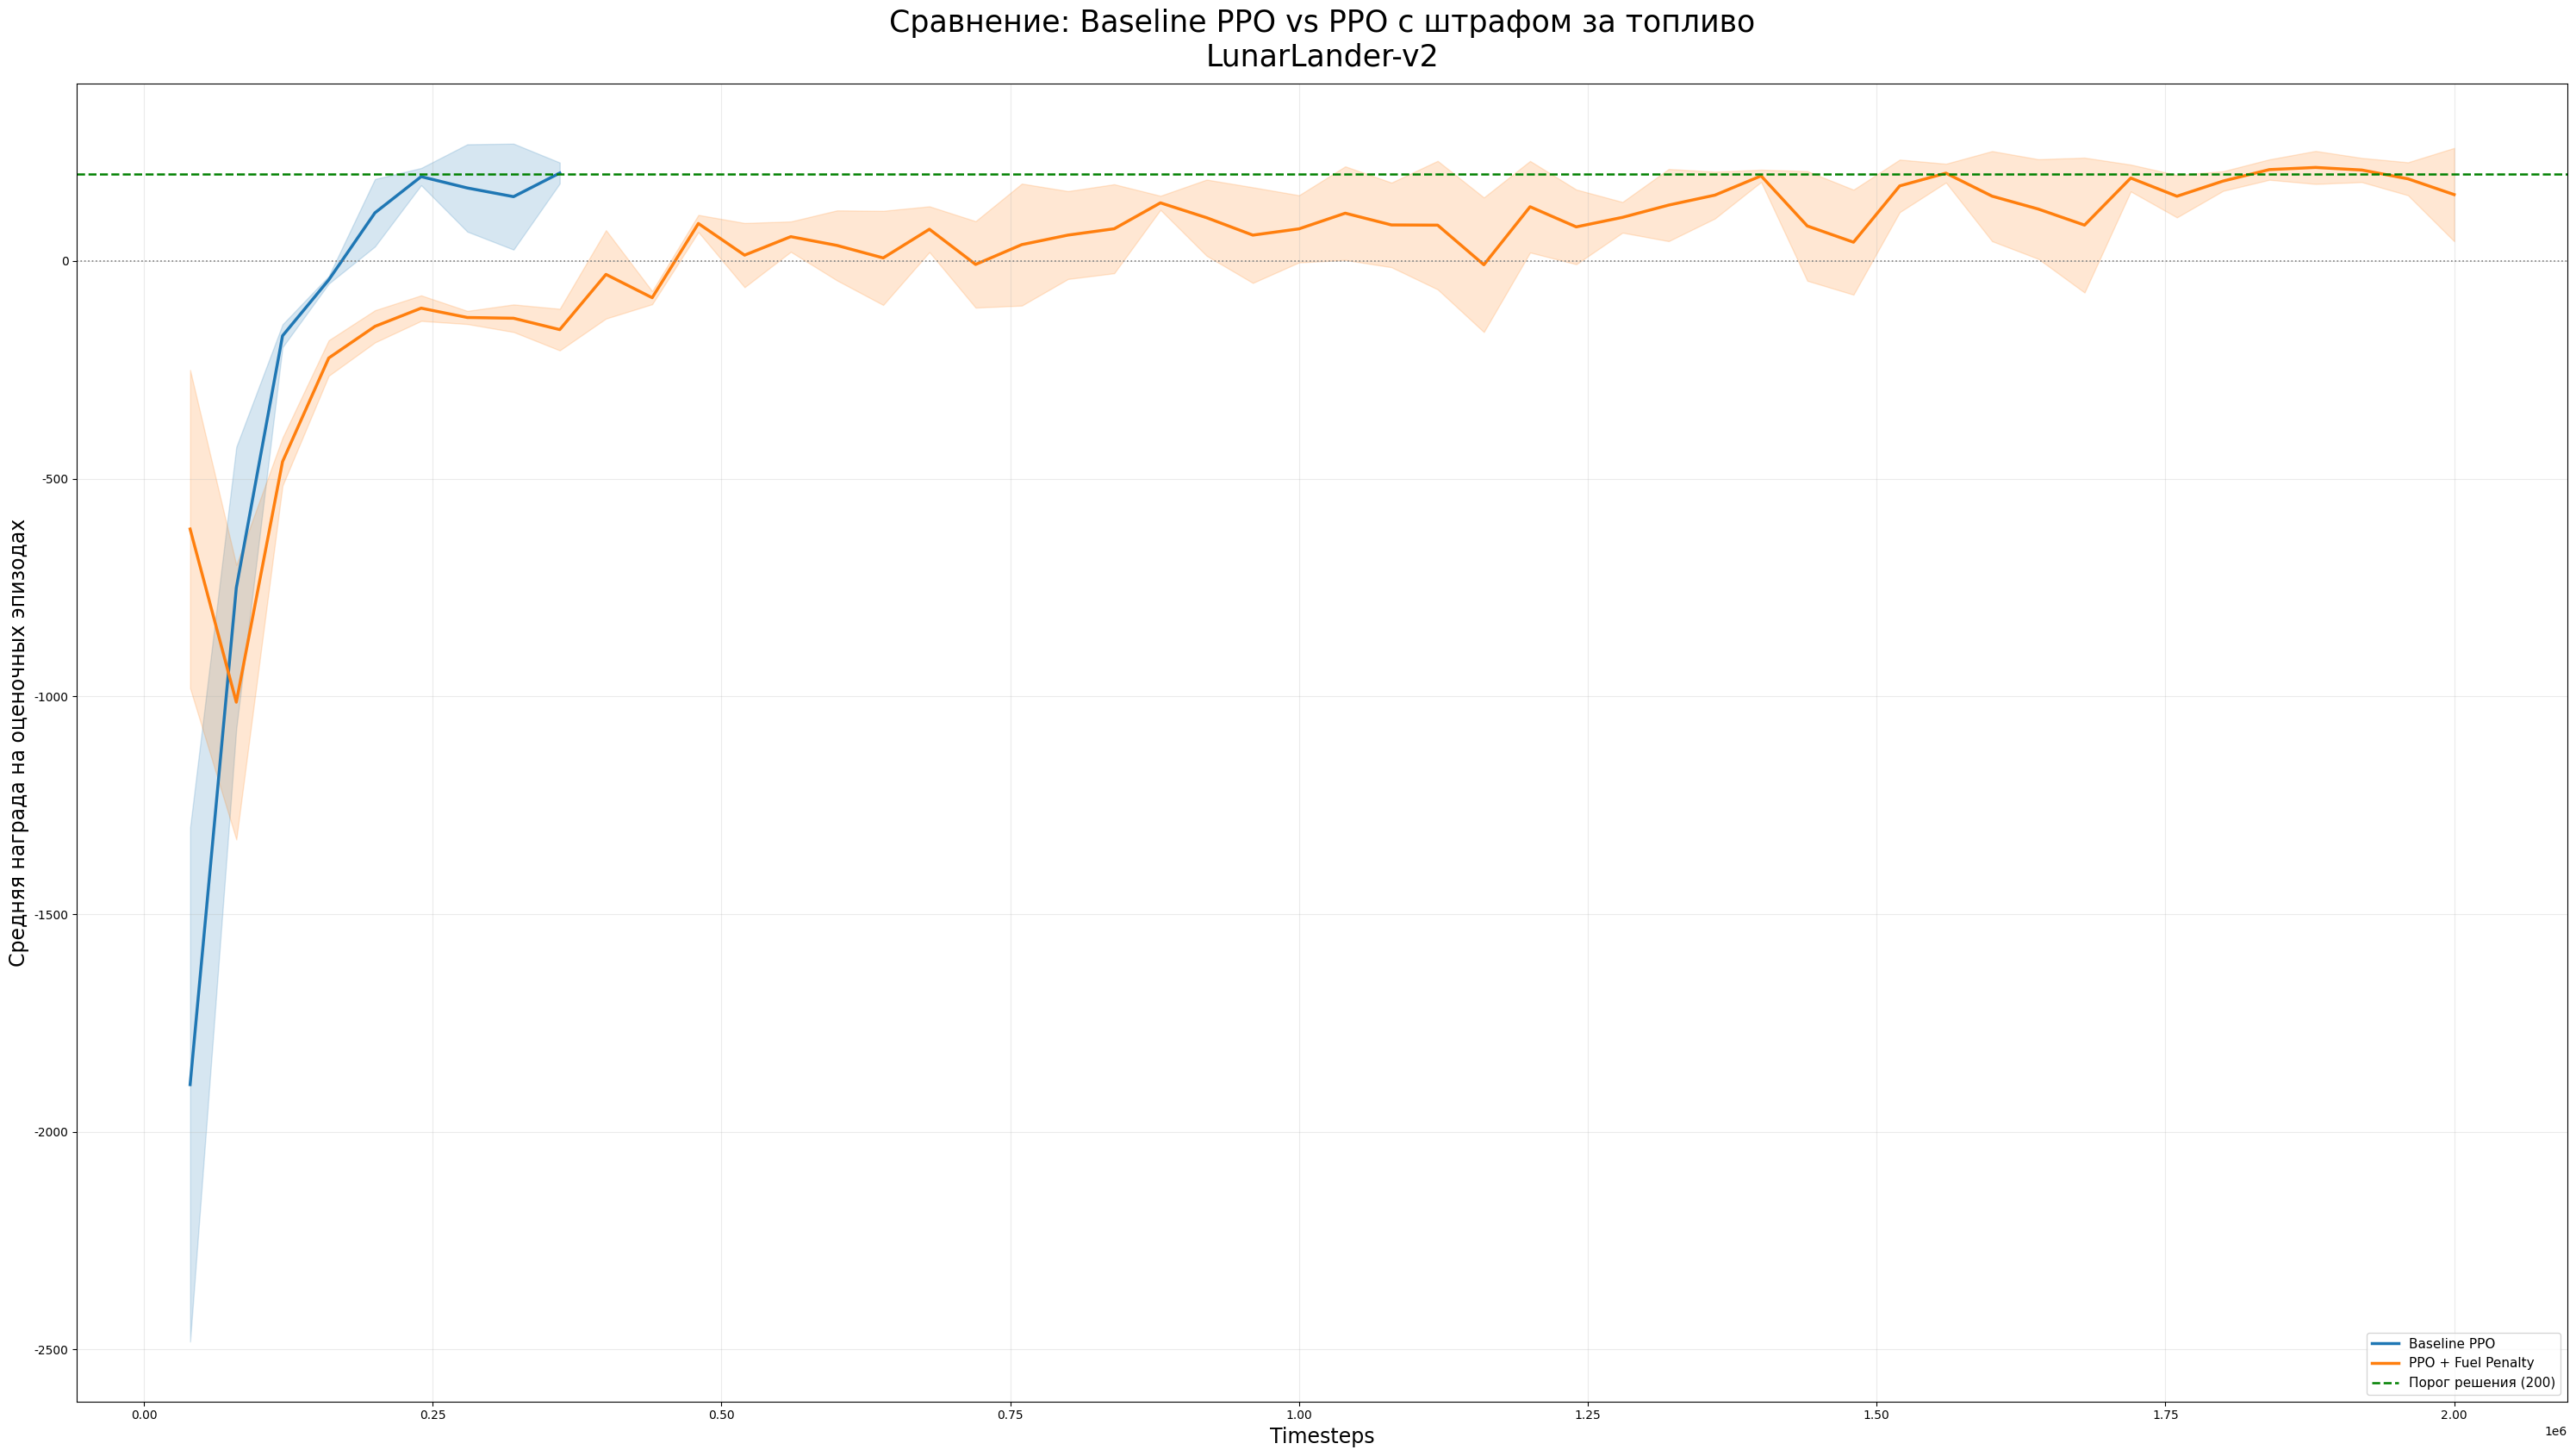

--------------------------------------------------------------------------------------------------------------


In [35]:
# Модель Baseline PPO 
data_base = np.load('./logs/evaluations.npz')
t_base   = data_base['timesteps']
mean_base = data_base['results'].mean(axis=1)
std_base  = data_base['results'].std(axis=1)

# Модель Shaped PPO
data_shaped = np.load('./logs_shaped/evaluations.npz')
t_shaped   = data_shaped['timesteps']
mean_shaped = data_shaped['results'].mean(axis=1)
std_shaped  = data_shaped['results'].std(axis=1)





# Задаём заголовок графика и подписи осей на русском языке
print('\n')
print('-' * 110)
print('====| Построение сравнительного графика Baseline PPO vs PPO с штрафом за топливо на среде LunarLander-v2 |====')
print('-' * 110)

# Настройка размера графика
plt.figure(figsize = (30, 17))


# Добавляем поддержку отображения минусовых значений
plt.rcParams['axes.unicode_minus'] = False


# Построение сравнительного графика
plt.plot(
    t_base,   
    mean_base,   
    label = 'Baseline PPO',   
    color = '#1f77b4', 
    linewidth = 2.5
)


# Добавление заливки для стандартного отклонения
plt.fill_between(
    t_base, 
    mean_base - std_base, 
    mean_base + std_base, 
    color = '#1f77b4', 
    alpha = 0.18
)


# Добавление данных для PPO с обёрткой
plt.plot(
    t_shaped, 
    mean_shaped, 
    label = 'PPO + Fuel Penalty', 
    color = '#ff7f0e', 
    linewidth = 2.5
)

# Добавление заливки для стандартного отклонения PPO с обёрткой
plt.fill_between(
    t_shaped, 
    mean_shaped - std_shaped, 
    mean_shaped + std_shaped, 
    color = '#ff7f0e', 
    alpha = 0.18
)

# Дополнительные улучшения
plt.axhline(y=200, color='green', linestyle='--', linewidth=1.8, label='Порог решения (200)')          # горизонтальная линия на уровне 200
plt.axhline(y=0,   color='gray',  linestyle=':',  linewidth=1.2)                                       # горизонтальная линия на уровне 0

plt.title('Сравнение: Baseline PPO vs PPO с штрафом за топливо\nLunarLander-v2', fontsize=25, pad=15)  # заголовок графика
plt.xlabel('Timesteps', fontsize = 17)                                                                 # подпись оси X
plt.ylabel('Средняя награда на оценочных эпизодах', fontsize = 17)                                     # подпись оси Y
plt.grid(True, alpha = 0.25)                                                                           # сетка с прозрачностью 0.3
plt.legend(fontsize=11, loc='lower right')                                                             # легенда графика
plt.tight_layout()                                                                                     # оптимизация компоновки графика



# Показываем график
plt.show()
print('-' * 110)

Запускаем видео:

In [37]:
# Записываем видео работы модели PPO со штрафом за топливо
video_ppo_shared = record_video(PPO_model_shaped, filename='lunarlander_ppo_fuel_penalty.mp4')



# Задаём заголовок для видео
print('\n')
print('-' * 110)
print('======================| Видео работы модели PPO со штрафом за топливо на среде LunarLander-v3 |======================')
print('-' * 110)

# Отображаем видео
display(video_ppo_shared)
print('-' * 110)



--------------------------------------------------------------------------------------------------------------
======================| Видео работы модели PPO со штрафом за топливо на среде LunarLander-v3 |======================
--------------------------------------------------------------------------------------------------------------


--------------------------------------------------------------------------------------------------------------


#### **Вывод:**

Добавление штрафа за использование двигателей значительно снижает расход топлива — это видно по более плавным и экономным траекториям в видео.

При этом средняя награда падает на $30–40$% (с $200–220$ до $140–160$), а обучение замедляется в $3–4$ раза.

Гипотеза полностью подтвердилась: существует явная зависимость между максимизацией награды и экономией ресурса.

Такой подход оправдан в задачах, где топливо/энергия критичны (реальные космические аппараты, дроны), даже если жертвуется немного производительностью.

Сохраняем модель:

In [32]:
# Сохраняем модель как 'ppo_lunarlander_shaped'
PPO_model_shaped.save('ppo_lunarlander_shaped')

=======================================================================================================================================

## <CENTER> **`3.` Краткий анализ**

В ходе работы были предложены и проверены следующие гипотезы:

  * **PPO** будет учиться быстрее и стабильнее, чем **A2C**, из-за нормализации преимущества и обрезанной целевой функции.
   
  * Добавление дополнительного штрафа сделает посадку более экономной по топливу, но может немного снизить итоговую награду и замедлить обучение.


Самое сильное ухудшение результатов наблюдалось при переходе на алгоритм **A2C** (фактически не обучается). В тоже время самое сильное улучшение наблюдалось при применении штрафа за топливо.


**Идеи для дальнейших шагов:**


* Попробовать алгоритмы `SAC` или `TD3` (off-policy);

* Более продвинутый штраф;

* Сделать штраф динамическим (например, большой в начале, маленький в конце);

* Добавить бонус за мягкое приземление (± маленькая скорость ног);

* Сравнить несколько вариантов штрафа ($0.05/0.01$, $0.2/0.05$ и т.д.);

* Добавить шум Гаусса в наблюдения;

* Сделать ветер сильнее/случайнее;

* Добавить ограничение топлива и посмотреть, кто проживёт дольше.


---